## 1️⃣ Importation & Exploration


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("bank-transaction.csv")
df=pd.read_csv("bank-transaction.csv")
df.columns=df.columns.str.lower().str.strip()
df.head()
df.dtypes
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       2060 non-null   object 
 1   client_id            2060 non-null   object 
 2   date_transaction     2060 non-null   object 
 3   montant              2060 non-null   object 
 4   devise               2060 non-null   object 
 5   taux_change_eur      2060 non-null   float64
 6   montant_eur          2060 non-null   float64
 7   categorie            2060 non-null   object 
 8   produit              2060 non-null   object 
 9   agence               1996 non-null   object 
 10  type_operation       2060 non-null   object 
 11  statut               2060 non-null   object 
 12  score_credit_client  1893 non-null   float64
 13  segment_client       1955 non-null   object 
 14  solde_avant          2060 non-null   object 
 15  taux_interet         0 non-null      f

,taux_change_eur,montant_eur,score_credit_client,taux_interet
count,2060.000000,2060.000000,1893.000000,0.0
mean,1.534782,-116.223170,627.866350,NaN
std,2.234708,2083.777234,132.193879,NaN
min,0.860000,-8705.810000,-100.000000,NaN
25%,1.000000,-1218.870000,586.000000,NaN
50%,1.000000,-60.405000,643.000000,NaN
75%,1.000000,957.805000,701.000000,NaN
max,10.850000,9026.940000,1500.000000,NaN


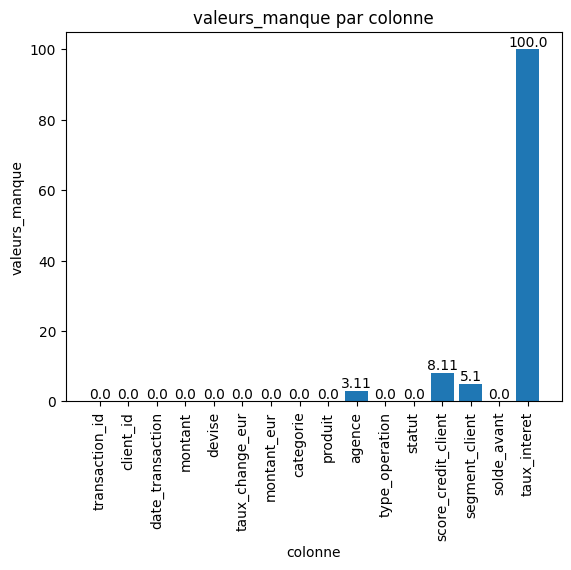

In [3]:
v_manque=df.isnull().sum()/df.shape[0]*100
v_manque
plt.bar(v_manque.index,v_manque.values)
plt.xticks(rotation=90)
for ind,vl in enumerate(v_manque.values):
    plt.text(ind,vl,str(vl.round(2)),ha="center",va="bottom")
plt.xlabel("colonne")
plt.ylabel("valeurs_manque")
plt.title("valeurs_manque par colonne")
plt.show()

In [4]:
duplicate=df[df.duplicated(subset=["transaction_id"],keep=False)]
duplicate=duplicate.sort_values(by="transaction_id")
duplicate=duplicate.groupby("transaction_id")["date_transaction"].nunique()
duplicate

transaction_id
TXN000034    2
TXN000052    2
TXN000116    2
TXN000121    2
TXN000127    2
TXN000150    2
TXN000157    2
TXN000177    2
TXN000192    2
TXN000209    2
TXN000223    2
TXN000267    2
TXN000270    2
TXN000363    2
TXN000418    2
TXN000437    2
TXN000479    2
TXN000484    2
TXN000493    2
TXN000510    2
TXN000547    2
TXN000558    2
TXN000601    2
TXN000611    2
TXN000612    2
TXN000620    2
TXN000661    2
TXN000669    2
TXN000690    2
TXN000784    2
TXN000945    2
TXN000967    2
TXN000990    2
TXN001032    2
TXN001093    2
TXN001114    2
TXN001272    2
TXN001313    2
TXN001315    2
TXN001328    2
TXN001344    2
TXN001417    2
TXN001433    2
TXN001448    2
TXN001449    2
TXN001469    2
TXN001489    2
TXN001522    2
TXN001598    2
TXN001729    2
TXN001739    2
TXN001748    2
TXN001764    2
TXN001792    2
TXN001817    2
TXN001857    2
TXN001868    2
TXN001890    2
TXN001961    2
TXN001990    2
Name: date_transaction, dtype: int64

## 2️⃣ Nettoyage des données



In [5]:
df.drop_duplicates(subset="transaction_id",keep="first",inplace=True)
df["date_transaction"] = pd.to_datetime(df["date_transaction"],errors="coerce",dayfirst=True)
df["montant"]=df["montant"].astype(str)
df["montant"]=df["montant"].str.replace(",",".")
df["montant"]=pd.to_numeric(df["montant"],errors="coerce").astype(float)
df["solde_avant"]=df["solde_avant"].astype(str)
df[df["solde_avant"].str.contains("EUR")]
df["solde_avant"]=df["solde_avant"].str.replace(" EUR","")
df["solde_avant"]=pd.to_numeric(df["solde_avant"]).astype(float)
df["devise"]=df["devise"].str.upper().str.strip()
df["segment_client"]=df["segment_client"].str.capitalize()
df["agence"]=df["agence"].str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2059
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       2000 non-null   object        
 1   client_id            2000 non-null   object        
 2   date_transaction     1925 non-null   datetime64[ns]
 3   montant              2000 non-null   float64       
 4   devise               2000 non-null   object        
 5   taux_change_eur      2000 non-null   float64       
 6   montant_eur          2000 non-null   float64       
 7   categorie            2000 non-null   object        
 8   produit              2000 non-null   object        
 9   agence               1940 non-null   object        
 10  type_operation       2000 non-null   object        
 11  statut               2000 non-null   object        
 12  score_credit_client  1840 non-null   float64       
 13  segment_client       1900 non-null   o

C:\Users\user\AppData\Local\Temp\ipykernel_9164\1264662269.py:2: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date_transaction"] = pd.to_datetime(df["date_transaction"],errors="coerce",dayfirst=True)


In [6]:
mode_date=df["date_transaction"].mode()[0]
mode_agenge=df["agence"].mode()[0]
mode_segment=df["segment_client"].mode()[0]
df["score_credit_client"]=df["score_credit_client"].fillna(df["score_credit_client"].median())
df["agence"]=df["agence"].fillna(mode_agenge)
df["segment_client"]=df["segment_client"].fillna(mode_segment)
df["date_transaction"]=df["date_transaction"].fillna(mode_date)
df=df.drop(columns="taux_interet",errors="ignore")

## 3️⃣ Détection & Traitement des Valeurs Aberrantes



In [7]:
Q1=df["montant"].quantile(0.25)
Q3=df["montant"].quantile(0.75)
IQR=Q3-Q1
val_max=Q3+1.5*IQR
val_min=Q1-1.5*IQR
anomalie_montant=(df["montant"]<val_min)|(df["montant"]>val_max)


In [8]:
Q1_1=df["score_credit_client"].quantile(0.25)
Q3_3=df["score_credit_client"].quantile(0.75)
IQR_score=Q3_3-Q1_1
v_max=Q3_3+1.5*IQR_score
v_min=Q1_1-1.5*IQR_score
anomalie_score_credit = (df["score_credit_client"] < v_min) | (df["score_credit_client"] > v_max) 
anomalie_score=(df["score_credit_client"]< 0) | (df["score_credit_client"]>850)
df["is_anomalie"]= anomalie_montant | anomalie_score_credit
a=df["is_anomalie"].value_counts()
a

is_anomalie
False    1687
True      313
Name: count, dtype: int64

 ## 4️⃣ Feature Engineering

In [9]:
df["annee"]=df["date_transaction"].dt.year
df["mois"]=df["date_transaction"].dt.month
df["trimestre"]=df["date_transaction"].dt.quarter
df["semaine-jour"]=df["date_transaction"].dt.dayofweek

In [10]:
df["montant_eur_verifie"]=(df["montant"]/df["taux_change_eur"]).round(2)
comparer=(df["montant_eur"]).compare(df["montant_eur_verifie"])
comparer

,self,other
21,264.77,99999.99
84,-1429.14,-103358.14
110,-2309.67,99999.99
191,377.08,-200000.00
194,-1499.86,0.00
220,-2323.20,-88888.00
239,1323.95,99999.99
322,-2140.03,0.00
325,-6934.61,-88888.00
353,1401.12,-200000.00


In [11]:
def risque(ca):
    if ca >=700: 
        return "Low"
    elif ca>=580:
        return "Meduim"
    else:
        return "High"
df["categorie_risque"]=df["score_credit_client"].apply(risque)
df["type_operation"]

0       Credit
1        Debit
2        Debit
3       Credit
4       Credit
         ...  
2054     Debit
2056    Credit
2057     Debit
2058     Debit
2059     Debit
Name: type_operation, Length: 2000, dtype: object

In [12]:
total_credit=df[df["type_operation"]=="Credit"].groupby("client_id")["montant"].sum()
total_debit=df[df["type_operation"]=="Debit"].groupby("client_id")["montant"].sum()
solde=pd.DataFrame({
    "total_credit":total_credit.round(2),
    "total_debit":total_debit.round(2)
}).reset_index()
df=pd.merge(df,solde, on="client_id")


In [13]:
df["solde_net"]=(df["total_credit"]-df["total_debit"]).round(2)
df.columns

Index(['transaction_id', 'client_id', 'date_transaction', 'montant', 'devise',
       'taux_change_eur', 'montant_eur', 'categorie', 'produit', 'agence',
       'type_operation', 'statut', 'score_credit_client', 'segment_client',
       'solde_avant', 'is_anomalie', 'annee', 'mois', 'trimestre',
       'semaine-jour', 'montant_eur_verifie', 'categorie_risque',
       'total_credit', 'total_debit', 'solde_net'],
      dtype='object')

In [14]:
stats = df.groupby("client_id").agg(
    nb_transaction=("transaction_id","count"),
    montant_moyen=("montant","mean"),
    nb_produit=("produit","nunique")
).reset_index().round(2)
stats
stats=pd.DataFrame(stats)
df=pd.merge(df,stats,on="client_id").reset_index()

In [15]:
df["taux_rejet"] = df.groupby('agence')['statut'].transform(
    lambda x: (x == 'Rejete').mean() * 100
).round(2)
df.head()

,index,transaction_id,client_id,date_transaction,montant,devise,taux_change_eur,montant_eur,categorie,produit,...,semaine-jour,montant_eur_verifie,categorie_risque,total_credit,total_debit,solde_net,nb_transaction,montant_moyen,nb_produit,taux_rejet
0,0,TXN000559,CLI0060,2022-04-19 02:31:00,2050.42,EUR,1.00,2050.42,Depot especes,Compte Epargne,...,1,2050.42,Meduim,18004.80,-3594.34,21599.14,12,1200.87,7,5.57
1,1,TXN001154,CLI0057,2024-06-20 20:51:00,-123.66,GBP,0.86,-143.79,Retrait DAB,Credit Consommation,...,3,-143.79,High,1791.74,-5203.97,6995.71,9,-379.14,7,4.59
2,2,TXN000764,CLI0015,2024-08-28 05:03:00,-396.17,EUR,1.00,-396.17,Prelevement,PEA,...,2,-396.17,Meduim,3752.75,-7055.30,10808.05,11,-300.23,5,4.01
3,3,TXN001598,CLI0045,2024-01-07 08:16:00,225.20,EUR,1.00,225.20,Paiement CB,Credit Consommation,...,6,225.20,Low,6754.81,-17480.49,24235.30,17,-630.92,7,4.59
4,4,TXN001873,CLI0034,2024-08-11 19:52:00,935.32,EUR,1.00,935.32,Interets,Credit Immobilier,...,6,935.32,High,5899.91,-5556.31,11456.22,13,26.43,6,4.59


In [16]:
df.to_csv("financecore_clean.csv",index=False)